In [76]:
import numpy as np
import pandas as pd
import seaborn as sns
import sqlite3







In [77]:
# import  database/ data
conn=sqlite3.connect(r'D:\customer_churn.db')

sql_query="""
           select name 
           from sqlite_master
           where type='table'


"""
tables = pd.read_sql(sql_query, conn)

for table_name in tables['name']:
    print("Table:", table_name)
    query = f"SELECT * FROM [{table_name}]"
    df = pd.read_sql(query, conn)
    globals()[f"df_{table_name}"] = df
    print(f"created dataframe: df_{table_name}")


conn.close

Table: db_customer
created dataframe: df_db_customer
Table: db_subscription
created dataframe: df_db_subscription
Table: db_support
created dataframe: df_db_support


<function Connection.close()>

In [84]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


 # 2 Data Cleaning

In [85]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [86]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [120]:
# a.rename col
# b.drop columns:intrest and pincode
#c.change data type:dop
# data standarization
# fix missing value
# 

In [87]:
# a.rename col
df_db_customer.rename(columns={'name': 'customer_name'},inplace=True)


In [88]:
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,None


In [89]:

# b.drop columns:intrest and pincode

df_db_customer.drop(df_db_customer.columns[-2:],axis=1,inplace=True)


In [124]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [90]:
# change Data types
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

In [91]:
# d.data standardization-gender
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'male','women':'female'})

In [92]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        18 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


In [93]:
#  fix missing values>>country
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [94]:
#country and state >>>unique value pair

state_country_mapping=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country']=df_db_customer['country'].fillna (df_db_customer['state'].map(state_country_mapping))

In [61]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [95]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [96]:
date_col=['subscription_start_date','renewal_date','cancellation_date']

In [97]:
df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()


<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [98]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [99]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [100]:
df_db_support.drop(columns=['col_1','comment'],inplace=True)

In [101]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerid      9 non-null      str  
 1   complaint_date  9 non-null      str  
 2   escalations     9 non-null      str  
 3   csat_score      9 non-null      int64
dtypes: int64(1), str(3)
memory usage: 420.0 bytes


In [102]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])

# Feature Engineering and Data Analysis

In [139]:
# crate new column
df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [138]:
# first fix support table and merge
df=(df_db_subscription
    .merge(df_db_customer,on='customerid',how='left')
    .merge(df_db_support,on='customerid',how='left'))

In [139]:
df.shape

(23, 20)

In [71]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN


In [106]:
df_db_customer['customerid'].nunique()

21

In [107]:
df_db_subscription['customerid'].nunique()

21

In [108]:
df_db_support['customerid'].nunique()

7

In [109]:
df_db_support['customerid'].size

9

In [110]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [111]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

# Data Analysis

In [112]:
df.to_csv('exported_churn_data.csv',index=False)

In [140]:
# churn rate
churn_rate=df['churn_flag'].mean()*100
print('churn_rate=',round(churn_rate,2),"%")

churn_rate= 28.57 %


In [114]:
#2.Retenion Rate
Rention_rate=100-churn_rate
print("Rentention_rate=",round(Rention_rate,2),"%")

Rentention_rate= 65.22 %


In [27]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN


In [115]:
# churn by plan type
chur_by_plan=(df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pet'))
print("churn by plan=",chur_by_plan)

churn by plan=   plan_type  churn_rate_pet
0     Basic           66.67
1   Premium           25.00
2  Standard           22.22


In [116]:
# Average revenue per user
arpu=df['monthly_charges'].mean()
print('arpu= ',round(arpu,2))



arpu=  18.51


In [117]:

df['subscription_start_date'] = pd.to_datetime(df['subscription_start_date'])

In [118]:
# average customer tenure
# count of days users has used our service: concallation date else current date

today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)
df.head()
avg_tenure=df['tenure_days'].mean()
print('avg tenure (days)=',avg_tenure)

avg tenure (days)= 1490.0


In [119]:
# Revenue at loss
revenue_at_risk=df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("revenue_at_risk(Rs 'k')=",revenue_at_risk)


revenue_at_risk(Rs 'k')= 103.91999999999999


In [120]:
# Escalation rate
escalation_rate=(df['escalations']=='Y').mean()*100
print('Esclation Rate=',round(escalation_rate,2),'%')

Esclation Rate= 21.74 %


In [121]:
df['complaint_count'] = df['complaint_date'].notna().astype(int)
df['complaint_count'].count()

np.int64(23)

In [122]:
# Average complaint per User
avg_complaints=df['complaint_count'].sum()/df['customerid'].nunique()
print('avg complaint per user=',round(avg_complaints,2))

avg complaint per user= 0.43


In [144]:
df['escalations'] = df['escalations'].map({'Y': 1, 'N': 0})

In [145]:
print(df['escalations'].unique())

[nan  1.  0.]


In [49]:
df.tail(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,gender,dob,interests,pincode,complaint_date,escalations,csat_score,tenure_days,complaint_count,churn_risk
21,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,NaT,NaN,22.99,1955,...,male,1991-05-14,NaN,None,NaT,0,NaN,2280.0,0,low
22,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,NaT,NaN,13.99,790,...,Women,1977-10-06,NaN,None,NaT,0,NaN,1359.0,0,low


In [146]:
# Correlation Escalation vs Churn

# encoding string to int type
corr_df=df[['escalations','churn_flag']].dropna()


In [147]:
correlation=df['escalations'].corr(df['churn_flag'])
print('correlation between escalation vs churn is =',round(correlation,2))

correlation between escalation vs churn is = 0.47


In [148]:
# churn risk  >>create a column using existing col
conditions=[
    (df['churn_score']<50),
    (df['churn_score']>=50) & (df['churn_score']<70),
    (df['churn_score']>=70)
]
choices=['low','med','high']
df['churn_risk']=np.select(conditions,choices,default='unknown')

In [149]:
df[['churn_risk','churn_score']].tail()

,churn_risk,churn_score
16,med,62
17,low,27
18,high,99
19,low,7
20,low,47


In [150]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,1.0,10.0,2.0,high


In [151]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'churn_risk'],
      dtype='str')

# Visulization using Matplotlib

In [152]:
import matplotlib.pyplot as plt

In [153]:
df_visual=df.copy()

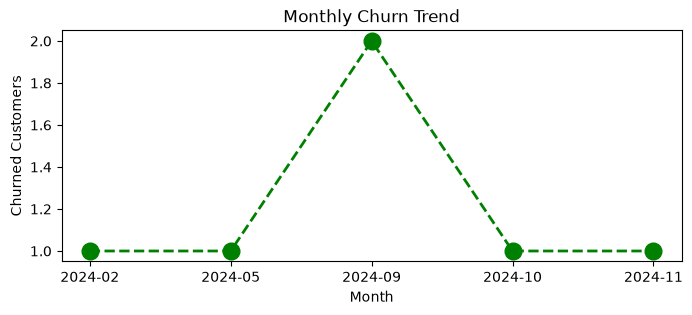

In [154]:
# monthly Churn Trend(time series KPI)
df_visual['cancellation_month']= (df_visual['cancellation_date'].dt.to_period('M'))
churn_trend=df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str),churn_trend.values,color='green',marker='o',linestyle='dashed',linewidth=2,markersize=12)
plt.title("Monthly Churn Trend")
plt.xlabel("Month")
plt.ylabel("Churned Customers")
plt.show()


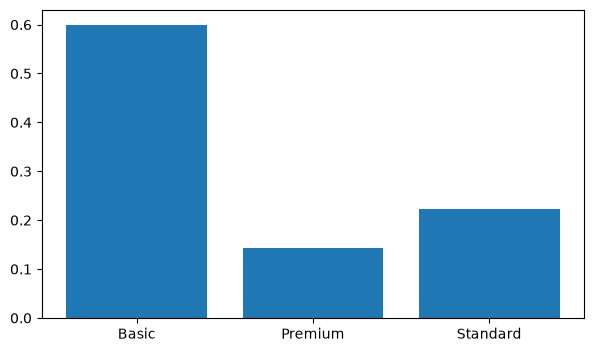

In [155]:
# churn by Plan type
churn_plan=df_visual.groupby('plan_type')['churn_flag'].mean()

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index,churn_plan.values)
plt.show()

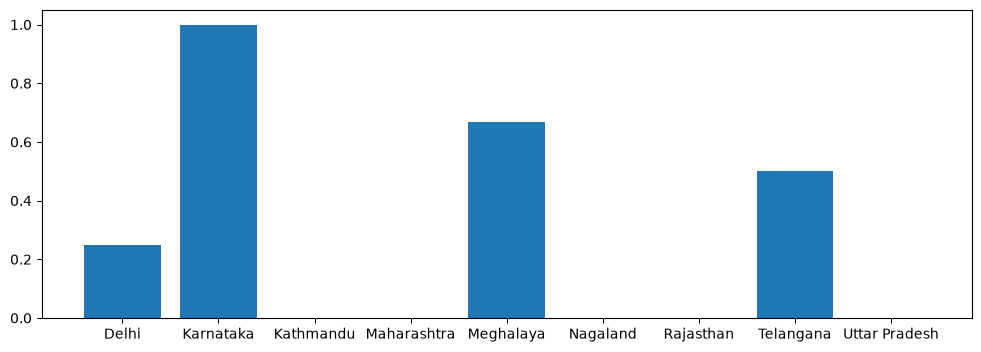

In [157]:
# churn by state
churn_plan=df_visual.groupby('state')['churn_flag'].mean()

plt.figure(figsize=(12,4))
plt.bar(churn_plan.index,churn_plan.values)
plt.show()

# Visulization using Seaborn

In [158]:
# encoding--- convert str to numeric so that we can find corr between feature
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'churn_risk', 'cancellation_month'],
      dtype='str')

In [ ]:
#incorect method of encoding -as numbers are not assigned based on priority
df_encoded=df_visual[['plan_type', 'contract_type', 'churn_score',
       'churn_flag', 'escalations'
    ,'churn_risk']]
categorial_cols=['plan_type', 'contract_type','churn_risk']
for col in categorial_cols:
    df_encoded[col]=df_encoded[col].astype('category').cat.codes

In [165]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,2,0,12,0,NaN,1
1,1,0,91,1,1.0,0
2,0,1,34,0,NaN,1
3,1,0,8,0,NaN,1
4,2,1,88,1,1.0,0


<Axes: >

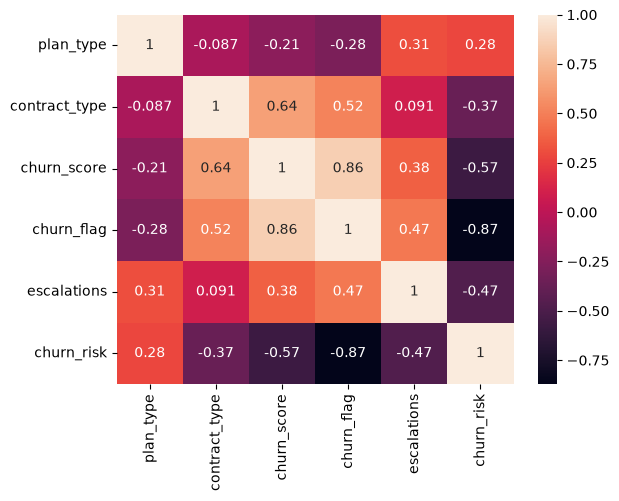

In [ ]:
#incorect method of correlation 
# headmap(correlation matrix)
sns.heatmap(df_encoded.corr(),annot=True)


In [168]:
#corect method of encoding -as numbers are not assigned based on priority
df_encoded=df_visual[['plan_type', 'contract_type', 'churn_score',
       'churn_flag', 'escalations'
    ,'churn_risk']]
order_mappings={
    'plan_type':['Basic','Standard','Premium'],
    'contract_type':['Monthly','Annual'],
    'churn_risk':['low','med','high']
}
for col, order in order_mappings.items():

    df_encoded[col]=pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes

In [169]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,1,1,12,0,NaN,0
1,2,1,91,1,1.0,2
2,0,0,34,0,NaN,0
3,2,1,8,0,NaN,0
4,1,0,88,1,1.0,2


<Axes: >

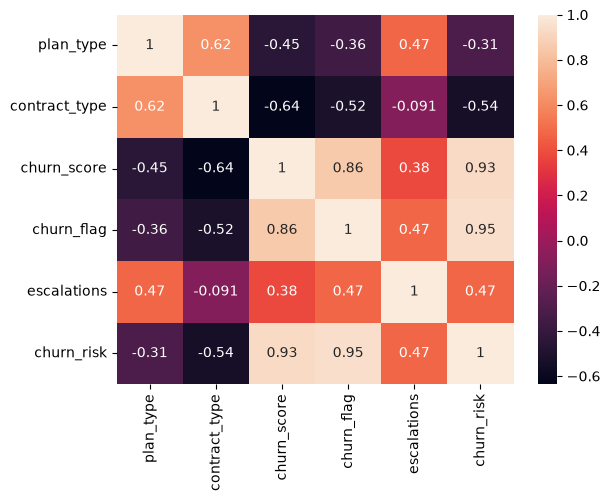

In [170]:
# headmap(correlation matrix)
sns.heatmap(df_encoded.corr(),annot=True)

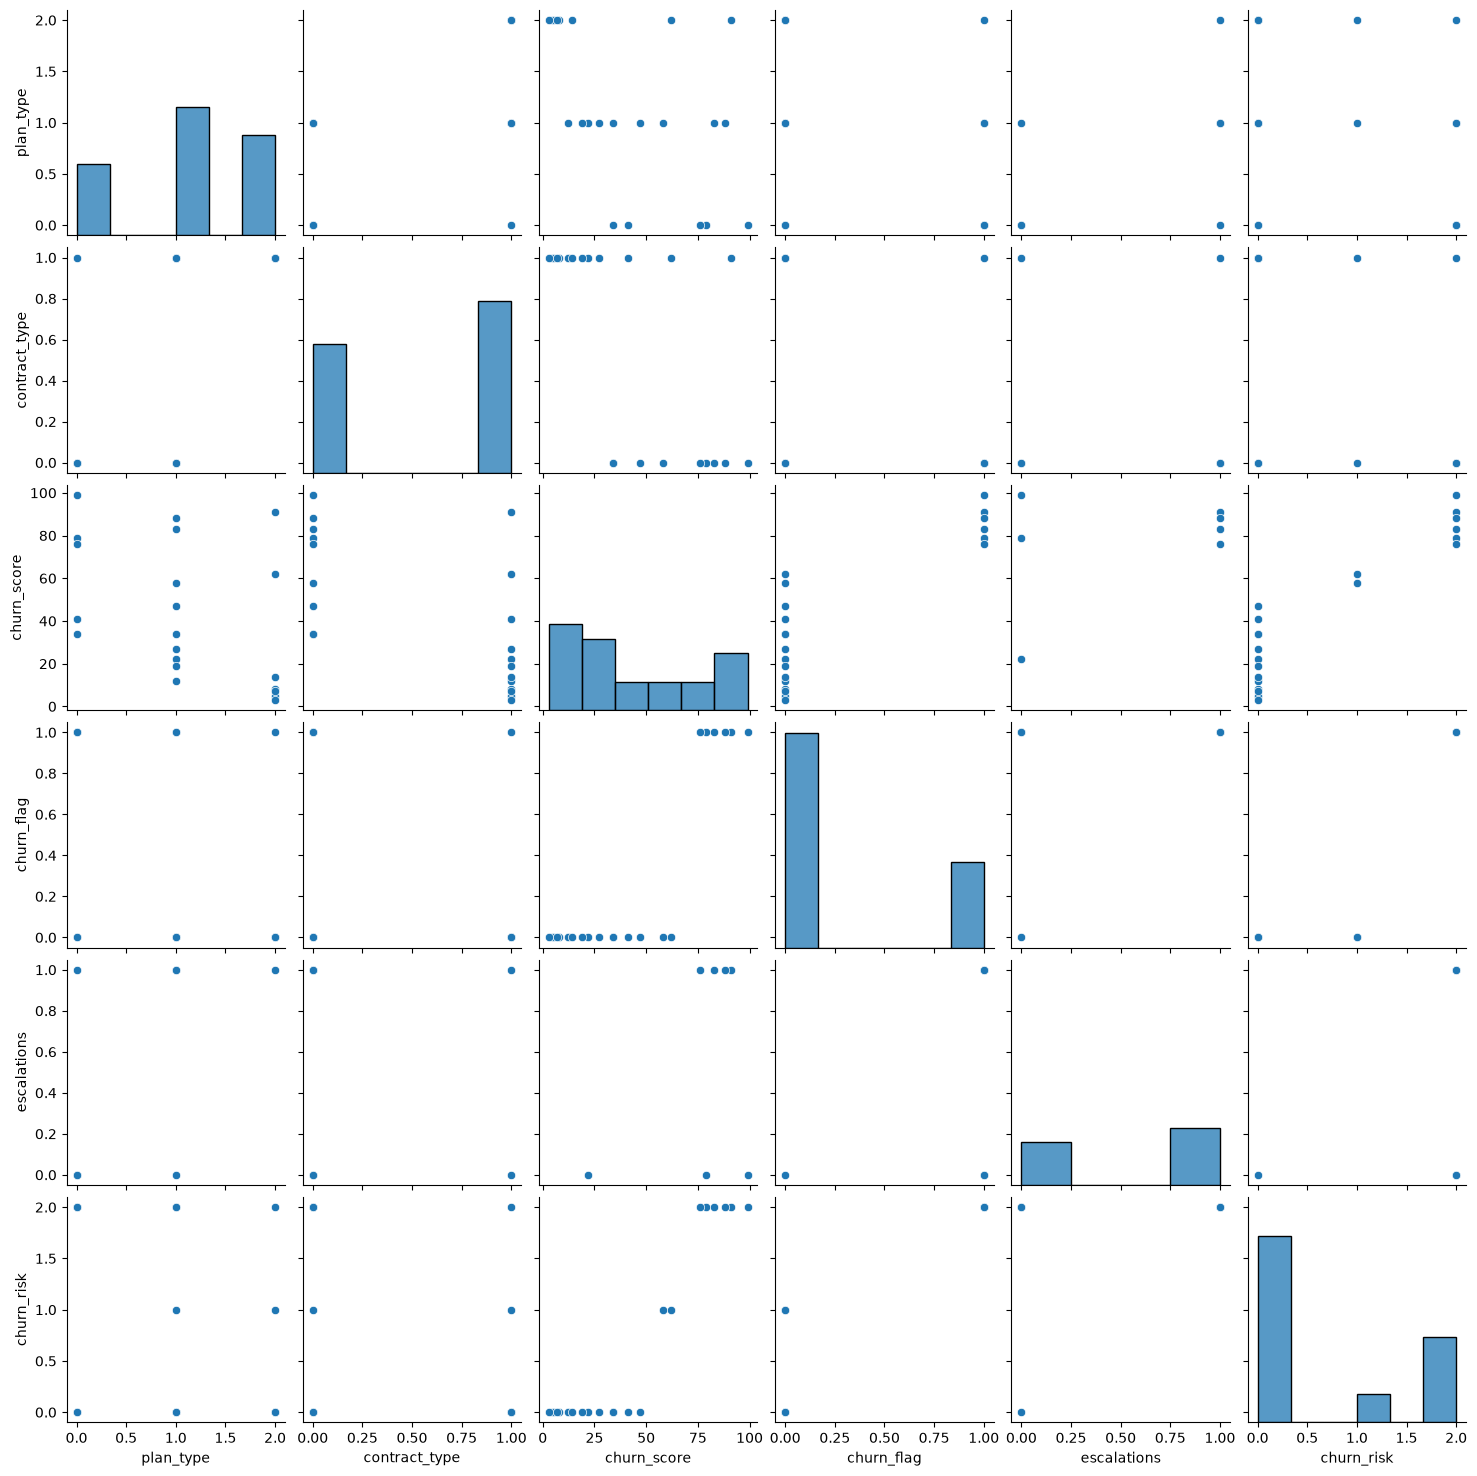

In [ ]:
# pairplot>>> relation in a dataset
sns.pairplot(df_encoded)

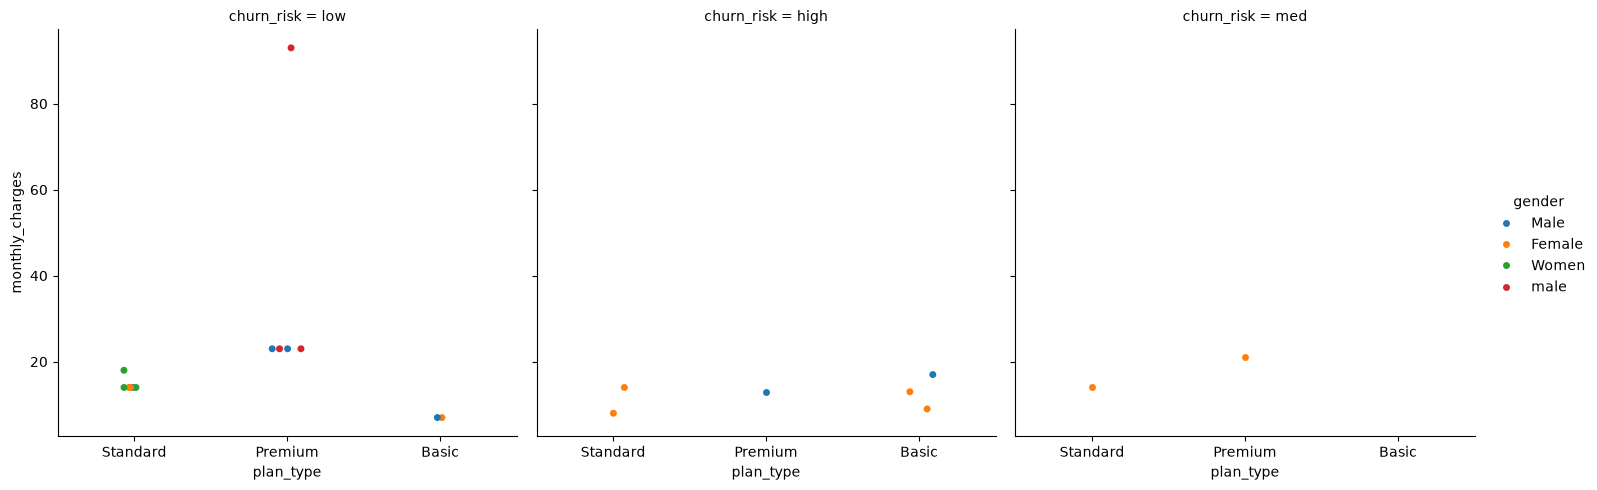

In [172]:
# catplt/ facegridplot>>> multi-dim comparison
sns.catplot(data=df_visual,
            x='plan_type',
            y='monthly_charges',
            hue='gender',
            col='churn_risk')

# Pivot Table

In [174]:
pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc='mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [176]:
pd.pivot_table(
    df_visual,
    values=['churn_flag','customerid','monthly_charges'],
    index='plan_type',
    aggfunc={
        'monthly_charges':'sum',
        'customerid':'nunique',
        'churn_flag':'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


# working with sql in python(pandas)

In [178]:
# create db in sql
conn=sqlite3.connect('test_database.sqlite')

#table details
conn.execute("CREATE TABLE USERS(first_name TEXT,country TEXT,budget INTEGER )" )
 # COMMIT AND SAVE
conn.commit()

In [184]:
# insert data
cursor = conn.cursor()

cursor.execute("""
    INSERT INTO USERS
    VALUES
        ('madhav', 'india', 3221),
        ('supriya', 'Melborn', 781821)
""")

conn.commit()

In [185]:
# check inserted data in table
conn=sqlite3.connect('test_database.sqlite')
query=""" select *from USERS"""
df_results=pd.read_sql(query,conn)
df_results.head()

,first_name,country,budget
0,madhav,india,3221
1,supriya,Melborn,781821


In [186]:
conn.close()